# Module 20.1 Capstone: Early-Stage Wildfire Severity & Growth Prediction
**Research Question:** Can a machine learning model accurately predict the potential severity and growth of a wildfire based on its initial ignition and environmental conditions to optimize early emergency resource allocation?

## 1. Environment Setup & Library Imports
In this cell, we import standard libraries for data manipulation (`pandas`, `numpy`), visual analytics (`matplotlib`, `seaborn`), and machine learning (`scikit-learn`).

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.metrics import (
    classification_report, 
    ConfusionMatrixDisplay, 
    precision_recall_curve, 
    auc
)

# Plotting configuration
sns.set_theme(style="ticks")
plt.rcParams.update({'font.size': 11, 'figure.autolayout': True})

## 2. Data Ingestion & Preprocessing
Here we load `FW_Veg_Rem_Combined.csv` from the `data/` subfolder. We select antecedent atmospheric windows (30, 15, and 7 days prior to fire discovery), geospatial indicators, and target metrics.

* **Data Cleaning:** Duplicates and missing atmospheric observations are removed.
* **Month Standardization:** `discovery_month` is converted from string names to numerical integers (1–12) to ensure model compatibility.
* **Target Definition:** High-severity fires are defined as NWCG Classes **E, F, or G** ($\ge 300$ acres burned).

In [6]:
# Load dataset from data subfolder
data_filepath = 'data/FW_Veg_Rem_Combined.csv'
data = pd.read_csv(data_filepath)

# Pre-ignition weather windows (30, 15, and 7 days prior)
antecedent_weather = [
    'Temp_pre_30', 'Temp_pre_15', 'Temp_pre_7',
    'Wind_pre_30', 'Wind_pre_15', 'Wind_pre_7',
    'Hum_pre_30',  'Hum_pre_15',  'Hum_pre_7',
    'Prec_pre_30', 'Prec_pre_15', 'Prec_pre_7'
]

geospatial_features = ['latitude', 'longitude', 'remoteness', 'Vegetation', 'discovery_month']
target_cols = ['fire_size', 'fire_size_class', 'fire_mag']

# Subset and remove duplicate records
model_df = data[antecedent_weather + geospatial_features + target_cols].copy()
model_df = model_df.drop_duplicates().dropna().reset_index(drop=True)

# Map text months ('Jan', 'Aug', etc.) to numeric integers (1-12)
month_mapping = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12,
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}

if model_df['discovery_month'].dtype == 'object':
    model_df['discovery_month'] = model_df['discovery_month'].map(month_mapping).fillna(
        pd.to_numeric(model_df['discovery_month'], errors='coerce')
    )

# Define high-severity wildfires as Class E, F, or G (>= 300 acres)
model_df['is_high_severity'] = model_df['fire_size_class'].isin(['E', 'F', 'G']).astype(int)

print(f"Dataset ready: {model_df.shape[0]:,} records, {model_df.shape[1]} features.")
print(f"High-severity baseline frequency: {model_df['is_high_severity'].mean():.2%}\n")

Dataset ready: 55,337 records, 21 features.
High-severity baseline frequency: 12.00%



## 3. Exploratory Data Analysis (EDA)
We explore key relationships between environmental predictors and wildfire severity:
1. **Wind Speed:** Comparing 7-day pre-fire wind speeds across NWCG size classes A–G.
2. **Temperature & Humidity:** Analyzing atmospheric drying conditions at ignition.
3. **Vegetation Types:** Assessing high-severity fire proportions across prominent ecosystem categories.
4. **Collinearity Heatmap:** Evaluating correlation across historical weather windows.

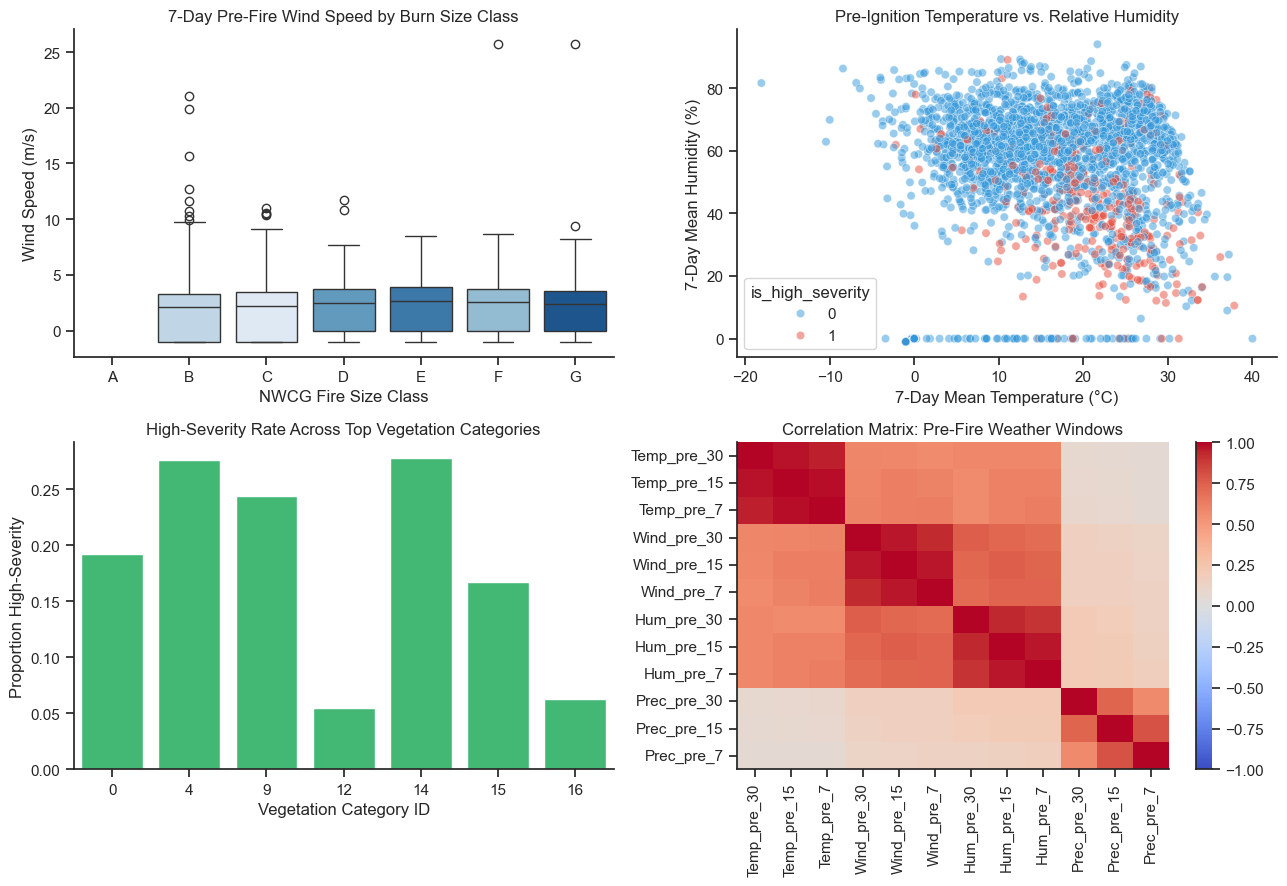

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Wind speed vs. Fire Size Class
sns.boxplot(
    data=model_df, x='fire_size_class', y='Wind_pre_7', 
    ax=axes[0, 0], order=['A', 'B', 'C', 'D', 'E', 'F', 'G'], 
    hue='fire_size_class', palette='Blues', legend=False
)
axes[0, 0].set_title('7-Day Pre-Fire Wind Speed by Burn Size Class')
axes[0, 0].set_xlabel('NWCG Fire Size Class')
axes[0, 0].set_ylabel('Wind Speed (m/s)')

# 2. Temp vs Humidity interaction (sampled for clarity)
sample_df = model_df.sample(n=min(4000, len(model_df)), random_state=42)
sns.scatterplot(
    data=sample_df, x='Temp_pre_7', y='Hum_pre_7', 
    hue='is_high_severity', alpha=0.5, ax=axes[0, 1], palette={0: '#3498db', 1: '#e74c3c'}
)
axes[0, 1].set_title('Pre-Ignition Temperature vs. Relative Humidity')
axes[0, 1].set_xlabel('7-Day Mean Temperature (°C)')
axes[0, 1].set_ylabel('7-Day Mean Humidity (%)')

# 3. High severity rate across prominent vegetation types
top_veg_types = model_df['Vegetation'].value_counts().head(8).index
veg_analysis = model_df[model_df['Vegetation'].isin(top_veg_types)]

sns.barplot(
    data=veg_analysis, x='Vegetation', y='is_high_severity', 
    ax=axes[1, 0], errorbar=None, color='#2ecc71'
)
axes[1, 0].set_title('High-Severity Rate Across Top Vegetation Categories')
axes[1, 0].set_xlabel('Vegetation Category ID')
axes[1, 0].set_ylabel('Proportion High-Severity')

# 4. Correlation matrix across weather windows
weather_corr = model_df[antecedent_weather].corr()
sns.heatmap(weather_corr, ax=axes[1, 1], cmap='coolwarm', vmin=-1, vmax=1)
axes[1, 1].set_title('Correlation Matrix: Pre-Fire Weather Windows')

sns.despine()
plt.savefig('wildfire_eda_overview.png', dpi=300)
plt.show()

## 4. Dimensionality Reduction (PCA) & Unsupervised Clustering (K-Means)
To address the strong collinearity observed in the weather heatmap:
* **Principal Component Analysis (PCA):** Extracts primary uncorrelated atmospheric signals (`weather_pc1` and `weather_pc2`).
* **K-Means Clustering:** Segments spatial location (`latitude`, `longitude`) combined with 30-day climate baselines into regional `climate_zone` clusters.

In [8]:

# PCA on weather features
scaler_pca = StandardScaler()
weather_scaled = scaler_pca.fit_transform(model_df[antecedent_weather])

pca = PCA(n_components=2, random_state=42)
pca_comps = pca.fit_transform(weather_scaled)

model_df['weather_pc1'] = pca_comps[:, 0]
model_df['weather_pc2'] = pca_comps[:, 1]
print(f"PCA Variance Explained (PC1 & PC2): {pca.explained_variance_ratio_.sum():.2%}")

# K-Means Clustering for spatial climate zones
geo_climate_features = ['latitude', 'longitude', 'Temp_pre_30', 'Hum_pre_30']
scaler_clusters = StandardScaler()
geo_scaled = scaler_clusters.fit_transform(model_df[geo_climate_features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
model_df['climate_zone'] = kmeans.fit_predict(geo_scaled)


PCA Variance Explained (PC1 & PC2): 76.74%


## 5. Feature Importance via LASSO Regression
We fit a 5-fold cross-validated **LASSO Regression** model on log-transformed burn acreages (`log1p(fire_size)`) to evaluate which continuous predictors retain the highest predictive power.

In [9]:
lasso_predictors = antecedent_weather + ['latitude', 'longitude', 'remoteness', 'Vegetation', 'weather_pc1', 'weather_pc2']
X_lasso = model_df[lasso_predictors]
y_lasso = np.log1p(model_df['fire_size'])

scaler_lasso = StandardScaler()
X_lasso_scaled = scaler_lasso.fit_transform(X_lasso)

lasso_model = LassoCV(cv=5, random_state=42).fit(X_lasso_scaled, y_lasso)
lasso_weights = pd.Series(lasso_model.coef_, index=lasso_predictors)

print("LASSO Feature Weights (Log Burn Size):")
print(lasso_weights[lasso_weights != 0].sort_values(ascending=False))

LASSO Feature Weights (Log Burn Size):
Temp_pre_7     0.334488
Wind_pre_30    0.151843
Wind_pre_15    0.151808
latitude       0.120124
Prec_pre_15    0.004505
Prec_pre_30   -0.002129
Hum_pre_15    -0.036429
Temp_pre_15   -0.052360
Vegetation    -0.104716
Temp_pre_30   -0.107115
Hum_pre_30    -0.206970
Hum_pre_7     -0.208813
remoteness    -1.360528
longitude     -2.028008
dtype: float64


## 6. Baseline Classification Modeling & Evaluation
We build a baseline **Logistic Regression** classifier to predict `is_high_severity` at discovery time:
* **Stratified Split:** Preserves rare high-severity fire proportions (80/20 train/test split).
* **Class Weight Balancing:** Uses `class_weight='balanced'` to prevent bias toward minor fires.
* **Evaluation Metrics:** Evaluated using **Recall** and **Precision-Recall AUC (PR-AUC)** rather than Accuracy.

In [10]:
predictors = antecedent_weather + ['latitude', 'longitude', 'remoteness', 'Vegetation', 
                                   'discovery_month', 'weather_pc1', 'climate_zone']

# Ensure numeric typing
X = model_df[predictors].apply(pd.to_numeric, errors='coerce')
y = model_df['is_high_severity']

valid_indices = X.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices]

# Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scaling
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train)
X_test_scaled = scaler_final.transform(X_test)

# Train Classifier
classifier = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
classifier.fit(X_train_scaled, y_train)

# Predictions
y_pred = classifier.predict(X_test_scaled)
y_probs = classifier.predict_proba(X_test_scaled)[:, 1]

print("--- Model Performance Summary ---")
print(classification_report(y_test, y_pred, target_names=['Standard Fire', 'Severe Fire']))

--- Model Performance Summary ---
               precision    recall  f1-score   support

Standard Fire       0.96      0.81      0.88      9740
  Severe Fire       0.35      0.78      0.49      1328

     accuracy                           0.80     11068
    macro avg       0.66      0.79      0.68     11068
 weighted avg       0.89      0.80      0.83     11068



## 7. Model Diagnostic Displays
We generate the **Confusion Matrix** and the **Precision-Recall Curve** to assess operational utility.

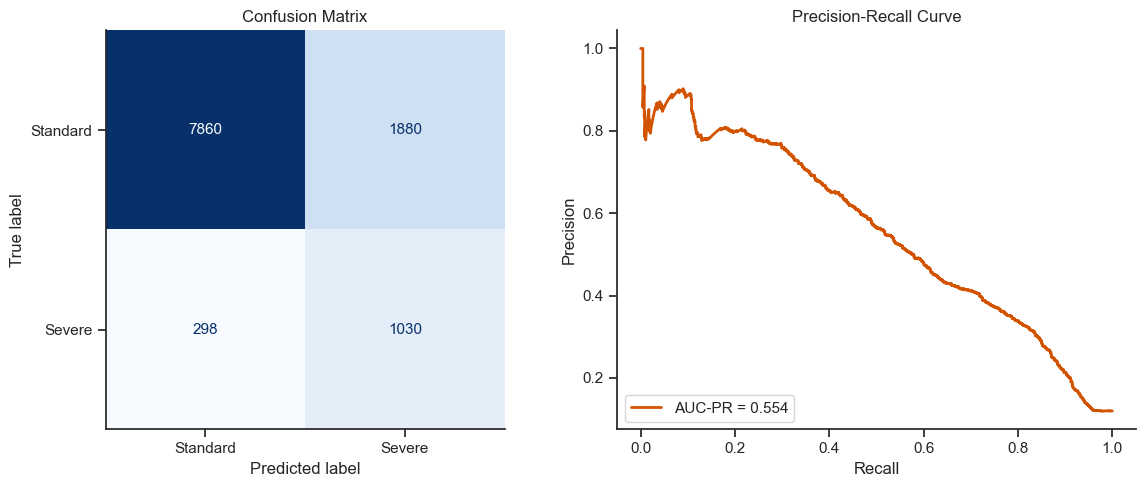

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Standard', 'Severe'], 
    cmap='Blues', ax=ax1, colorbar=False
)
ax1.set_title('Confusion Matrix')

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc_score = auc(recall, precision)

ax2.plot(recall, precision, color='#d35400', lw=2, label=f'AUC-PR = {pr_auc_score:.3f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc='lower left')

sns.despine()
plt.tight_layout()
plt.savefig('model_evaluation_metrics.png', dpi=300)
plt.show()